In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Read predictions for forward and revcomp

In [2]:
pred_500 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/predicted_all_yeast_full_knockout.csv")
pred_500_rc = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/predicted_all_yeast_full_knockout_rc.csv")

Calculate var effects for the forward df

In [3]:
split_cols = pred_500['motif_name'].str.split('_', n=1, expand=True)
pred_500['motif_group'] = split_cols[0]
pred_500['motif_type'] = split_cols[1]

pred_500_ref = pred_500[pred_500['motif_type'] != 'mut'].copy()
pred_500_alt = pred_500[pred_500['motif_type'] == 'mut'].copy()

pred_500_ref.drop(columns=['motif_type'], inplace=True)
pred_500_alt.drop(columns=['motif_type'], inplace=True)

pred_500_ref = pred_500_ref.rename(columns={col: f"ref_{col}" for col in pred_500_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
pred_500_alt = pred_500_alt.rename(columns={col: f"alt_{col}" for col in pred_500_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df = pd.merge(pred_500_ref, pred_500_alt, on=['seq_id', 'motif_group'], how='inner')

offsets = list(range(-30, 31, 1))

for offset in offsets:
    merged_df[f'diff_{offset}'] =  merged_df[f'ref_pred_seq_{offset}'] - merged_df[f'alt_pred_seq_{offset}']

avg_diff = merged_df.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()
print(avg_diff.head(2))

offset_cols = [col for col in avg_diff.columns if col.startswith("diff_")]

flipped_cols = {f'diff_{offset}': f'diff_{-int(offset)}' for offset in [col.split("_")[1] for col in offset_cols]}

avg_diff_flipped = avg_diff.rename(columns=flipped_cols)
avg_diff_flipped['strand'] = 'forward'
print(avg_diff_flipped.head(2))


  motif_group  diff_-30  diff_-29  diff_-28  diff_-27  diff_-26  diff_-25  \
0        Abf1  3.449827  3.478886  3.521900  3.536955  3.514280  3.506083   
1        Azf1  0.426407  0.437667  0.398998  0.366164  0.334724  0.302952   

   diff_-24  diff_-23  diff_-22  ...   diff_21   diff_22   diff_23   diff_24  \
0  3.467558  3.448646  3.477508  ...  3.682553  3.638349  3.631869  3.599308   
1  0.325117  0.347048  0.346165  ...  0.045432  0.053575  0.037136  0.020424   

    diff_25   diff_26   diff_27   diff_28   diff_29   diff_30  
0  3.558239  3.620392  3.558593  3.553776  3.556367  3.507226  
1  0.001412 -0.056691 -0.070913 -0.104163 -0.128918 -0.107315  

[2 rows x 62 columns]
  motif_group   diff_30   diff_29   diff_28   diff_27   diff_26   diff_25  \
0        Abf1  3.449827  3.478886  3.521900  3.536955  3.514280  3.506083   
1        Azf1  0.426407  0.437667  0.398998  0.366164  0.334724  0.302952   

    diff_24   diff_23   diff_22  ...  diff_-22  diff_-23  diff_-24  diff_-25  \


Calculate var effects for the reverse df

In [4]:
pred_500_rc['motif_group'] = pred_500_rc['motif_name'].str.split('_').str[0]
pred_500_rc['motif_type'] = pred_500_rc['motif_name'].str.split('_').str[1]

pred_500_rc_ref = pred_500_rc[pred_500_rc['motif_type'] != 'mut'].copy()
pred_500_rc_alt = pred_500_rc[pred_500_rc['motif_type'] == 'mut'].copy()

pred_500_rc_ref.drop(columns=['motif_type'], inplace=True)
pred_500_rc_alt.drop(columns=['motif_type'], inplace=True)

pred_500_rc_ref = pred_500_rc_ref.rename(columns={col: f"ref_{col}" for col in pred_500_rc_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
pred_500_rc_alt = pred_500_rc_alt.rename(columns={col: f"alt_{col}" for col in pred_500_rc_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df_rc = pd.merge(pred_500_rc_ref, pred_500_rc_alt, on=['seq_id', 'motif_group'], how='inner')

offsets = list(range(-30, 31, 1))

for offset in offsets:
    merged_df_rc[f'diff_{offset}'] = merged_df_rc[f'ref_pred_seq_{offset}'] - merged_df_rc[f'alt_pred_seq_{offset}']

avg_diff_rc = merged_df_rc.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()

Normalize each row

In [5]:
for_columns = [col for col in avg_diff_flipped.columns if col.startswith('diff')]
avg_diff_flipped[for_columns] = avg_diff_flipped[for_columns].div(avg_diff_flipped[for_columns].abs().max(axis=1), axis=0)

In [6]:
revcomp_columns = [col for col in avg_diff.columns if col.startswith('diff')]
avg_diff_rc[revcomp_columns] = avg_diff_rc[revcomp_columns].div(avg_diff_rc[revcomp_columns].abs().max(axis=1), axis=0)

In [7]:
avg_diff_flipped.head(5)

,motif_group,diff_30,diff_29,diff_28,diff_27,diff_26,diff_25,diff_24,diff_23,diff_22,...,diff_-22,diff_-23,diff_-24,diff_-25,diff_-26,diff_-27,diff_-28,diff_-29,diff_-30,strand
0,Abf1,0.936803,0.944694,0.956374,0.960463,0.954305,0.952079,0.941618,0.936482,0.944320,...,0.987996,0.986237,0.977395,0.966242,0.983120,0.966338,0.965031,0.965734,0.952390,forward
1,Azf1,0.974272,1.000000,0.911647,0.836627,0.764792,0.692197,0.742841,0.792950,0.790932,...,0.122411,0.084850,0.046665,0.003226,-0.129529,-0.162025,-0.237995,-0.294558,-0.245197,forward
2,Hap1,0.464741,0.542614,0.452102,0.477631,0.519626,0.541386,0.542545,0.553902,0.541335,...,0.858984,0.875411,0.899722,0.911291,0.916040,0.862513,1.000000,0.819852,0.802004,forward
3,Mga1,0.656804,0.784352,0.729646,0.833866,0.621565,0.281943,0.185724,0.013256,-0.086191,...,0.844890,1.000000,0.790990,0.722554,0.190039,-0.210847,-0.613169,-0.882133,-0.347366,forward
4,Mot3,0.419113,0.468814,0.419817,0.372274,0.365367,0.355846,0.378363,0.383197,0.425772,...,0.993417,0.963713,0.962756,0.969717,1.000000,0.975299,0.959560,0.968747,0.925874,forward


In [8]:
avg_diff_rc.head(5)

,motif_group,diff_-30,diff_-29,diff_-28,diff_-27,diff_-26,diff_-25,diff_-24,diff_-23,diff_-22,...,diff_21,diff_22,diff_23,diff_24,diff_25,diff_26,diff_27,diff_28,diff_29,diff_30
0,Abf1,0.946712,0.960382,0.981374,0.964965,0.974698,0.973189,1.000000,0.994619,0.987101,...,0.915951,0.911610,0.922187,0.933270,0.924397,0.950040,0.950927,0.940035,0.919602,0.877723
1,Azf1,0.542486,0.578855,0.548397,0.538566,0.464753,0.590498,0.610945,0.705671,0.813267,...,0.579648,0.589493,0.677455,0.667471,0.749065,0.639466,0.675607,0.768194,0.885546,1.000000
2,Hap1,0.898844,0.967483,0.866995,0.851023,0.857056,0.918077,0.939297,0.989852,0.998214,...,0.614982,0.571183,0.578467,0.572239,0.609371,0.633174,0.644201,0.652335,0.669887,0.709437
3,Mga1,-1.000000,-0.979304,-0.787330,-0.693526,-0.628789,-0.442217,-0.463524,-0.383288,-0.422652,...,0.109618,0.218094,0.389374,0.550775,0.706060,0.705982,0.644568,0.540374,0.326320,0.346381
4,Mot3,0.874882,0.925366,0.936598,1.000000,0.935357,0.953078,0.965357,0.950907,0.936888,...,0.499242,0.482516,0.487724,0.484951,0.456327,0.417731,0.389861,0.416554,0.434169,0.466851


In [9]:
avg_diff_flipped = avg_diff_flipped.rename(columns={col: f"{col}_for" for col in avg_diff_flipped.columns if col != 'motif_group'})
avg_diff_rc = avg_diff_rc.rename(columns={col: f"{col}_rc" for col in avg_diff_rc.columns if col != 'motif_group'})

In [10]:
merged_df = pd.merge(
    avg_diff_flipped,
    avg_diff_rc,
    on="motif_group"
)
merged_df.head(5)

,motif_group,diff_30_for,diff_29_for,diff_28_for,diff_27_for,diff_26_for,diff_25_for,diff_24_for,diff_23_for,diff_22_for,...,diff_21_rc,diff_22_rc,diff_23_rc,diff_24_rc,diff_25_rc,diff_26_rc,diff_27_rc,diff_28_rc,diff_29_rc,diff_30_rc
0,Abf1,0.936803,0.944694,0.956374,0.960463,0.954305,0.952079,0.941618,0.936482,0.944320,...,0.915951,0.911610,0.922187,0.933270,0.924397,0.950040,0.950927,0.940035,0.919602,0.877723
1,Azf1,0.974272,1.000000,0.911647,0.836627,0.764792,0.692197,0.742841,0.792950,0.790932,...,0.579648,0.589493,0.677455,0.667471,0.749065,0.639466,0.675607,0.768194,0.885546,1.000000
2,Hap1,0.464741,0.542614,0.452102,0.477631,0.519626,0.541386,0.542545,0.553902,0.541335,...,0.614982,0.571183,0.578467,0.572239,0.609371,0.633174,0.644201,0.652335,0.669887,0.709437
3,Mga1,0.656804,0.784352,0.729646,0.833866,0.621565,0.281943,0.185724,0.013256,-0.086191,...,0.109618,0.218094,0.389374,0.550775,0.706060,0.705982,0.644568,0.540374,0.326320,0.346381
4,Mot3,0.419113,0.468814,0.419817,0.372274,0.365367,0.355846,0.378363,0.383197,0.425772,...,0.499242,0.482516,0.487724,0.484951,0.456327,0.417731,0.389861,0.416554,0.434169,0.466851


Plot

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


all_columns = merged_df.columns.tolist()
print(all_columns)
position_columns = []

# Find forward columns (-80_for to 80_for)
for i in range(-30, 31):
    col_name = f"diff_{i}_for"
    if col_name in all_columns:
        position_columns.append(col_name)

# Find reverse complement columns (-80_revcomp to 80_revcomp)  
for i in range(-30, 31):
    col_name = f"diff_{i}_rc"
    if col_name in all_columns:
        position_columns.append(col_name)

print(f"Found {len(position_columns)} position columns for clustering")
print(f"Forward columns: {len([col for col in position_columns if col.endswith('_for')])}")
print(f"Revcomp columns: {len([col for col in position_columns if col.endswith('_rc')])}")

['motif_group', 'diff_30_for', 'diff_29_for', 'diff_28_for', 'diff_27_for', 'diff_26_for', 'diff_25_for', 'diff_24_for', 'diff_23_for', 'diff_22_for', 'diff_21_for', 'diff_20_for', 'diff_19_for', 'diff_18_for', 'diff_17_for', 'diff_16_for', 'diff_15_for', 'diff_14_for', 'diff_13_for', 'diff_12_for', 'diff_11_for', 'diff_10_for', 'diff_9_for', 'diff_8_for', 'diff_7_for', 'diff_6_for', 'diff_5_for', 'diff_4_for', 'diff_3_for', 'diff_2_for', 'diff_1_for', 'diff_0_for', 'diff_-1_for', 'diff_-2_for', 'diff_-3_for', 'diff_-4_for', 'diff_-5_for', 'diff_-6_for', 'diff_-7_for', 'diff_-8_for', 'diff_-9_for', 'diff_-10_for', 'diff_-11_for', 'diff_-12_for', 'diff_-13_for', 'diff_-14_for', 'diff_-15_for', 'diff_-16_for', 'diff_-17_for', 'diff_-18_for', 'diff_-19_for', 'diff_-20_for', 'diff_-21_for', 'diff_-22_for', 'diff_-23_for', 'diff_-24_for', 'diff_-25_for', 'diff_-26_for', 'diff_-27_for', 'diff_-28_for', 'diff_-29_for', 'diff_-30_for', 'strand_for', 'diff_-30_rc', 'diff_-29_rc', 'diff_-28_rc',

Plotting Forward clustermap...
Index(['motif_group', 'diff_30_for', 'diff_29_for', 'diff_28_for',
       'diff_27_for', 'diff_26_for', 'diff_25_for', 'diff_24_for',
       'diff_23_for', 'diff_22_for', 'diff_21_for', 'diff_20_for',
       'diff_19_for', 'diff_18_for', 'diff_17_for', 'diff_16_for',
       'diff_15_for', 'diff_14_for', 'diff_13_for', 'diff_12_for',
       'diff_11_for', 'diff_10_for', 'diff_9_for', 'diff_8_for', 'diff_7_for',
       'diff_6_for', 'diff_5_for', 'diff_4_for', 'diff_3_for', 'diff_2_for',
       'diff_1_for', 'diff_0_for', 'diff_-1_for', 'diff_-2_for', 'diff_-3_for',
       'diff_-4_for', 'diff_-5_for', 'diff_-6_for', 'diff_-7_for',
       'diff_-8_for', 'diff_-9_for', 'diff_-10_for', 'diff_-11_for',
       'diff_-12_for', 'diff_-13_for', 'diff_-14_for', 'diff_-15_for',
       'diff_-16_for', 'diff_-17_for', 'diff_-18_for', 'diff_-19_for',
       'diff_-20_for', 'diff_-21_for', 'diff_-22_for', 'diff_-23_for',
       'diff_-24_for', 'diff_-25_for', 'diff_-26_

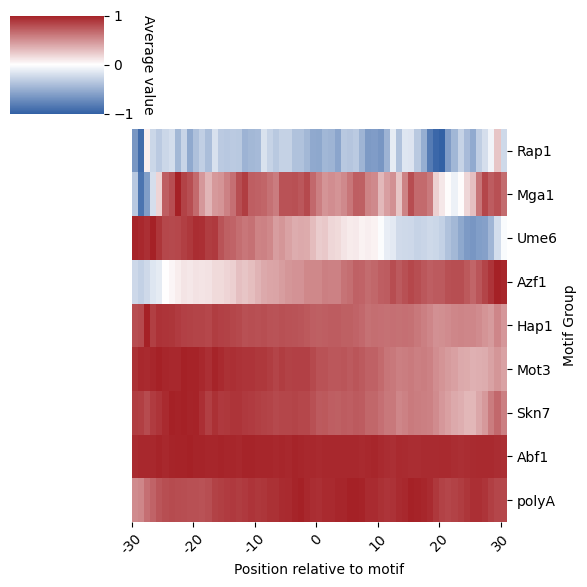

Plotting Reverse clustermap...
Index(['motif_group', 'diff_-30_rc', 'diff_-29_rc', 'diff_-28_rc',
       'diff_-27_rc', 'diff_-26_rc', 'diff_-25_rc', 'diff_-24_rc',
       'diff_-23_rc', 'diff_-22_rc', 'diff_-21_rc', 'diff_-20_rc',
       'diff_-19_rc', 'diff_-18_rc', 'diff_-17_rc', 'diff_-16_rc',
       'diff_-15_rc', 'diff_-14_rc', 'diff_-13_rc', 'diff_-12_rc',
       'diff_-11_rc', 'diff_-10_rc', 'diff_-9_rc', 'diff_-8_rc', 'diff_-7_rc',
       'diff_-6_rc', 'diff_-5_rc', 'diff_-4_rc', 'diff_-3_rc', 'diff_-2_rc',
       'diff_-1_rc', 'diff_0_rc', 'diff_1_rc', 'diff_2_rc', 'diff_3_rc',
       'diff_4_rc', 'diff_5_rc', 'diff_6_rc', 'diff_7_rc', 'diff_8_rc',
       'diff_9_rc', 'diff_10_rc', 'diff_11_rc', 'diff_12_rc', 'diff_13_rc',
       'diff_14_rc', 'diff_15_rc', 'diff_16_rc', 'diff_17_rc', 'diff_18_rc',
       'diff_19_rc', 'diff_20_rc', 'diff_21_rc', 'diff_22_rc', 'diff_23_rc',
       'diff_24_rc', 'diff_25_rc', 'diff_26_rc', 'diff_27_rc', 'diff_28_rc',
       'diff_29_rc', 'diff

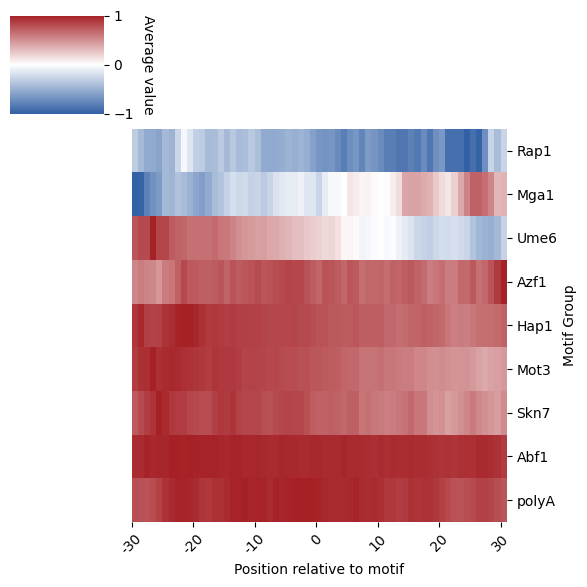


Hierarchical clustering completed!
Number of motif groups clustered: 9
First 10 motifs in order: ['Rap1', 'Mga1', 'Ume6', 'Azf1', 'Hap1', 'Mot3', 'Skn7', 'Abf1', 'polyA']


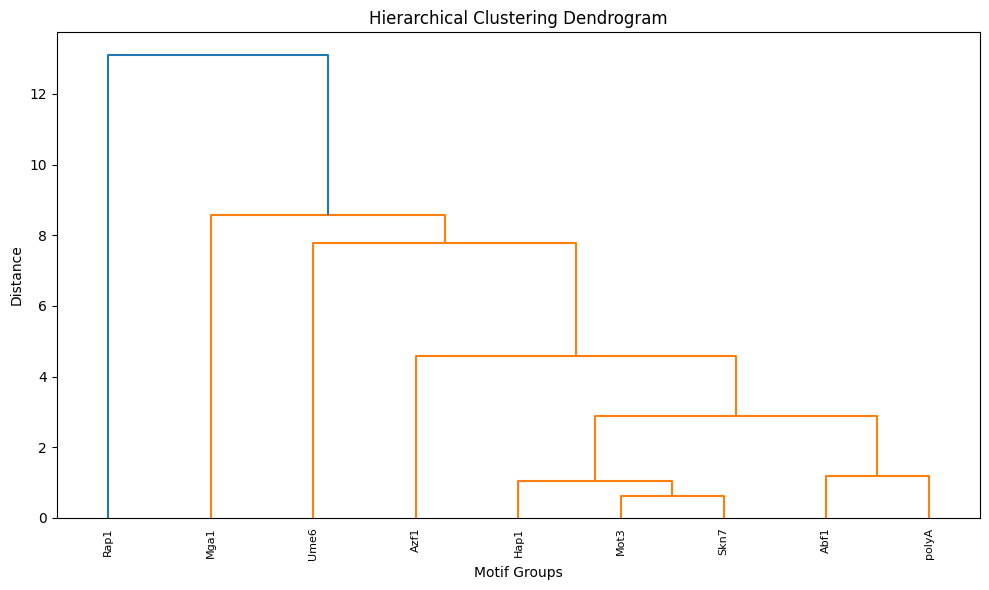

In [14]:
cluster_data = merged_df.set_index('motif_group')[position_columns].fillna(0)

# Step 3: Perform hierarchical clustering
row_distances = pdist(cluster_data, metric='euclidean')
row_linkage = linkage(row_distances, method='average')

# Get the row ordering from hierarchical clustering
row_order_indices = leaves_list(row_linkage)
motif_order = cluster_data.index[row_order_indices]

# Step 4: Custom colormap setup
vmin, vmax = -1, 1
white_pos = - vmin / (vmax - vmin)

colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, "#ffffff"),  # white at 0
    (1.0, "#A52126")         # dark red at max
]

cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)

# Step 5: Plotting function
def plot_hierarchical_clustermap(df, title, motif_order, orientation, save_path=None):
    # Get position columns for this orientation
    if orientation == "forward":
        suffix = "_for"
    else:  # reverse
        suffix = "_rc"
    
    print(df.columns)
    position_cols = [col for col in df.columns if col.startswith("diff")]
    # position_cols = [col.split("_")[1] for col in merged_df.columns if col.startswith("diff_")]
    print(position_cols)

    try:
        # position_cols.sort(key=lambda x: int(x.replace(suffix, '')))
        position_cols.sort(key=lambda col: int(col.split("_")[1]))

    except:
        pass  # If sorting fails, use original order
    
    # try:
    #     # positions = np.array([int(col.replace(suffix, '')) for col in position_cols])
    #     positions = np.array([col.split("_")[1] for col in position_cols])
    #     xticks_positions = np.arange(-30, 31, 10)
    #     xticks_indices = []
    #     for pos in xticks_positions:
    #         pos_matches = np.where(positions == pos)[0]
    #         if len(pos_matches) > 0:
    #             xticks_indices.append(pos_matches[0])
        
    #     # If no standard positions found, use evenly spaced indices
    #     if len(xticks_indices) == 0:
    #         n_ticks = min(9, len(position_cols))
    #         xticks_indices = np.linspace(0, len(position_cols)-1, n_ticks, dtype=int)
    #         xticks_positions = [positions[i] for i in xticks_indices]
    #         # xticks_positions = np.arange(min(positions), max(positions) + 1, 10)

            
    # except Exception as e:
    #     print(f"Position parsing failed: {e}")
    
    try:
    # Parse positions as integers
        positions = np.array([int(col.split("_")[1]) for col in position_cols])
        
        # Define xticks explicitly every 10 from -30 to 30
        xticks_positions = np.arange(-30, 31, 10)
        xticks_indices = [np.where(positions == pos)[0][0] 
                        for pos in xticks_positions if pos in positions]
    
    except Exception as e:
        print(f"Position parsing failed: {e}")
    
    # Create data matrix
    data_matrix = df.set_index('motif_group')[position_cols]
    
    # Reorder rows according to hierarchical clustering
    data_matrix_ordered = data_matrix.reindex(motif_order)
    
    # Plot clustermap
    g = sns.clustermap(
        data_matrix_ordered,
        cmap=cmap,
        row_cluster=False,  # Use our pre-computed hierarchical order
        col_cluster=False,  # Keep positions in original order
        figsize=(6, max(6, len(data_matrix_ordered) * 0.75 * 0.15)),
        yticklabels=True,
        xticklabels=False,
        vmin=vmin,
        vmax=vmax,
    )
    
    # Set x-axis ticks manually
    g.ax_heatmap.set_xticks(xticks_indices)
    g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)
    
    g.ax_heatmap.set_xlabel("Position relative to motif")
    g.ax_heatmap.set_ylabel("Motif Group")
    
    # Setup colorbar
    cbar = g.cax
    cbar.set_yticks([-1.0, 0, 1.0])
    cbar.set_ylabel("Average value", rotation=270, labelpad=15)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        # plt.savefig(save_path, format="svg")

    
    plt.show()
    
    return g

# Step 6: Plot both clustermaps
print("Plotting Forward clustermap...")
g1 = plot_hierarchical_clustermap(
    avg_diff_flipped, 
    "Forward",
    motif_order,
    "forward",
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/knockout_clustermap_forward_hierarchical_Ns.png"
)

print("Plotting Reverse clustermap...")
g2 = plot_hierarchical_clustermap(
    avg_diff_rc, 
    "Reverse",
    motif_order,
    "reverse",
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/knockout_clustermap_reverse_hierarchical_Ns.png"
)

# Optional: Print clustering information
print(f"\nHierarchical clustering completed!")
print(f"Number of motif groups clustered: {len(motif_order)}")
print(f"First 10 motifs in order: {list(motif_order[:10])}")

# Optional: Plot dendrogram
plt.figure(figsize=(10, 6))
from scipy.cluster.hierarchy import dendrogram
dendrogram(row_linkage, labels=cluster_data.index, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Motif Groups")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/hierarchical_dendrogram_Ns.svg", format="svg")
plt.show()